# Single qubit gates and visualisation
---

## 0.1 Imports

In [1]:
import numpy as np
from qiskit.visualization.bloch import Bloch

## 0.2 Helper functions

In [2]:
# Helper function to convert 1-qubit statevector 
# (|ψ⟩ = α|0⟩ + β|1) = quantum state of the probabilities of |0> and |1>) 
# to 3-dimensional Bloch coordinates x, y, z  
def statevector_to_bloch(statevec):
    alpha = statevec[0] # Probability amplitude for |0> (North Pole)
    beta = statevec[1] # Probability amplitude for |1> (South Pole)
    x = 2 * (alpha.conjugate() * beta).real
    y = 2 * (alpha.conjugate() * beta).imag
    z = abs(alpha)**2 - abs(beta)**2
    return [x, y, z]

# Visualizes quantum states of qubits, stored in vectors, 
# on the Bloch sphere with optional labels and colors.
def plot_bloch_states(vectors, labels=None, colors=None):
    b = Bloch()

    for v in vectors:
        b.add_vectors(v)

    if colors:
        b.vector_color = colors

    if labels:
        for v, label in zip(vectors, labels):
            b.add_annotation(v, label)

    b.show()

---
## 1. Single qubits

Let's start with the simplest building block of quantum computing, the single qubit. An arbitrary single qubit state can be written (in the computational basis) as:

$$\ket{\psi} = c_0 \ket{0} + c_1 \ket{1}$$

a qubit in its quantum state Psi and its probability of being 0 or 1 (with c0 and c1 being complex coefficients (amplitudes) that indicate how much of 0 or 1 is present in the state):

This equation can also be written as a vector:

$$\ket{\psi} = \begin{pmatrix}
c_0 \\
c_1
\end{pmatrix}$$

with $$ |c_0|^2 + |c_1|^2 = 1.$$

This is the normalization condition. It means the total probability of all possible outcomes must equal 100% (1), ensuring the system makes physical sense.

In summary: A qubit is not just 0 or 1, but a complex mix of both, represented as a vector, with probabilities that must sum to 1

For example the $\ket{0}$ state is $\begin{pmatrix}
1 \\
0
\end{pmatrix}$ and we can visualise this state on the Bloch sphere.

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


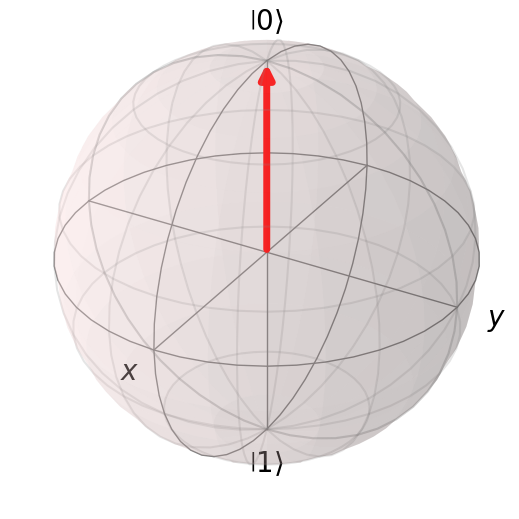

In [3]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Create a statevector for the label |0⟩, which corresponds 
# to the North Pole of the Bloch sphere
state = Statevector.from_label("0")

print(state)
# plot_bloch_multivector(state.data, title="|0⟩ state on the Bloch sphere")

bloch = statevector_to_bloch(state.data)
plot_bloch_states([bloch], colors=["r"])

---
## 2. Evolving a state with a quantum circuit

In qiskit, we change the state of our qubit(s) using QuantumCircuit objects. We can either initialise a state using the Statevector object, or just define the QuantumCircuit alone, in which case Qiskit will default to the 0 state for each qubit. 

Initial statevector: [1.+0.j 0.+0.j]
Final statevector: [0.+0.j 1.+0.j]


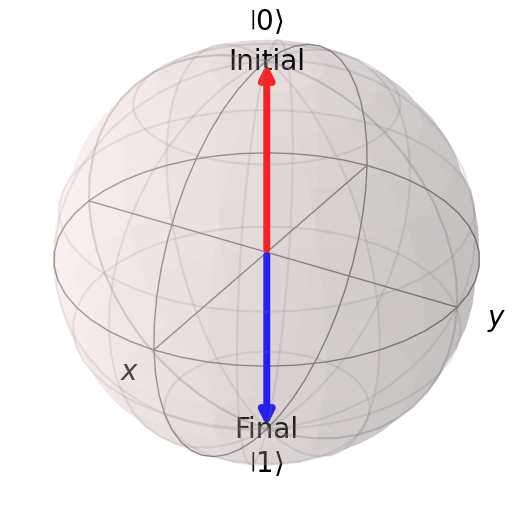

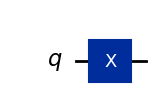

In [4]:
# 1. Define initial state
initial_state = Statevector.from_label("0")

# 2. Build quantum circuit
from qiskit import QuantumCircuit
qc = QuantumCircuit(1)
qc.x(0)

# 3. Evolve state using the circuit
final_state = initial_state.evolve(qc)

# 4. Print statevectors
print("Initial statevector:", initial_state.data)
print("Final statevector:", final_state.data)

# 5. Plot Bloch vectors
plot_bloch_states(
    [
        statevector_to_bloch(initial_state.data),
        statevector_to_bloch(final_state.data)
    ],
    labels=["Initial", "Final"],
    colors=["r", "b"]
)

qc.draw(output='mpl')

## Exercise (10 mins)

Play around with the code above by changing the initial state vector and the gate we apply. 

The different 'labels' for the single qubit state vectors are {0, 1, +, -, r, l}.

The different single qubit gates you can apply are:

| Gate             | Method     |
| ---------------- | ---------- | 
| **x**            | qc.x(q)    |
| **y**            | qc.y(q)    |
| **z**            | qc.z(q)    |
| **H**            | qc.h(q)    | 
| **S**            | qc.s(q)    | 
| **S†**           | qc.sdg(q)  |
| **T**            | qc.t(q)    |
| **T†**           | qc.tdg(q)  |
| **SX**           | qc.sx(q)   |
| **SX†**          | qc.sxdg(q) |

Can you come to some understanding what different gates do by visualising how they affect different state vectors? 

q1: Why does applying the z gate on the 0 and 1 statevectors seemingly do nothing?

q2: How are the S and Z gate related?

q3: How are the S and S† gate related?

## 2.1 H Gate

One of the most fundamental gates in quantum computing is the Hadamard gate. It is represented by the matrix:

$$
H =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix},
$$

and when applied to the $\ket{0}$ state, results in the $\ket{+}$ state:

$$
H \ket{0}=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
\begin{pmatrix}
1 \\
0
\end{pmatrix}
=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\
1
\end{pmatrix}
=
\frac{1}{\sqrt{2}}
\left(
\ket{0} + \ket{1}
\right)
=
\ket{+}.
$$

When applied to the $\ket{1}$ state, results in the $\ket{-}$ state:

$$
H \ket{1}=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
\begin{pmatrix}
0 \\
1
\end{pmatrix}
=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\
-1
\end{pmatrix}
=
\frac{1}{\sqrt{2}}
\left(
\ket{0} - \ket{1}
\right)
=
\ket{-}.
$$

Initial statevector: [1.+0.j 0.+0.j]
Final statevector: [0.70710678+0.j 0.70710678+0.j]


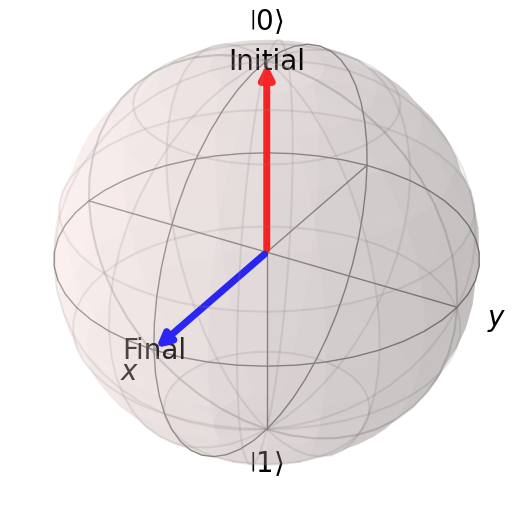

In [5]:
# 1. Define initial state
initial_state = Statevector.from_label('0')
# initial_state = Statevector([1, 0])
# initial_state = Statevector([1,1j] /np.sqrt(2))

# 2. Build circuit
qc = QuantumCircuit(1)
qc.h(0)

# 3. Evolve state
final_state = initial_state.evolve(qc)

# 4. Print statevectors
print("Initial statevector:", initial_state.data)
print("Final statevector:", final_state.data)

# 5. Plot Bloch vectors
plot_bloch_states(
    [
        statevector_to_bloch(initial_state.data),
        statevector_to_bloch(final_state.data)
    ],
    labels=["Initial", "Final"],
    colors=["r", "b"]
)

## Exercise

Try initialising different single qubit state vectors and evolving with the H gate. 

Q1. What happens if you apply the H gate twice in a row? Are there any initial states that don't behave this way?

Q2. What happens if you apply H, then Z, then H again on the $\ket{0}$ state? What circuit is this equivalent to?

---
#### We said in the first part that a general single qubit state can be written as $\ket{\psi} = c_0 \ket{0} + c_1 \ket{1}$.

#### The $\ket{0}$ state was one such example where $c_0=1$ and $c_1$=0. 

#### When we applied the Hadamard gate on $\ket{0}$ we got a new one $\frac{1}{\sqrt{2}}\left(\ket{0} + \ket{1}\right)$ where $c_0=c_1=\frac{1}{\sqrt{2}}$. This is an example of a superposition state, where our state is neither in 0 or 1, but somewhere 'in between'. 

#### The real power of quantum computing comes from the fact that we can directly apply gates on superposition states, and they apply linearly across all the components of that state. For example, you've probably figured out by now that the X gate changes $\ket{0} \xrightarrow{X} \ket{1}, \quad \ket{1} \xrightarrow{X} \ket{0}$. If we apply the X gate to a superposition state then it applies over all the components at once:

$X (\frac{1}{\sqrt{2}}\left(\ket{0} + \ket{1}\right)) = \frac{1}{\sqrt{2}}\left(X \ket{0} + X \ket{1}\right)) =  \frac{1}{\sqrt{2}}\left(\ket{1} + \ket{0}\right))$

#### This is the concept of linearity and it is one of the most important ingredients in quantum computing.

Initial statevector: [1.+0.j 0.+0.j]
Final statevector: [0.-0.70710678j 0.+0.70710678j]


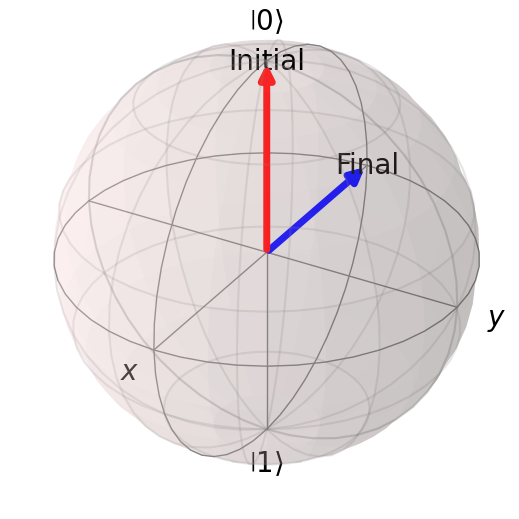

In [6]:
initial_state = Statevector.from_label('0')

qc = QuantumCircuit(1)
qc.h(0)

qc.y(0) # Gate applies over both the |0> and the |1> components of our superposition state

final_state = initial_state.evolve(qc)

print("Initial statevector:", initial_state.data)
print("Final statevector:", final_state.data)

plot_bloch_states(
    [
        statevector_to_bloch(initial_state.data),
        statevector_to_bloch(final_state.data)
    ],
    labels=["Initial", "Final"],
    colors=["r", "b"]
)

---
# 3. Measurement 

### Up to now, we’ve been working with the statevector, which describes a quantum state before measurement.
### Measurement is different:

* It is probabilistic

* It destroys the statevector description

* If we want to learn more about the state before measurement, we need to repeateadly measure it.

In [7]:
initial_state = Statevector.from_label("0")

qc = QuantumCircuit(1)
qc.h(0)

state = initial_state.evolve(qc)

print("Statevector:")
print(state.data)

print("\nMeasurement probabilities:")
print(state.probabilities_dict())

Statevector:
[0.70710678+0.j 0.70710678+0.j]

Measurement probabilities:
{np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


---
#### If you do happen to know the exact state before measurement then you can make some **predictions** on your measurement outcome. You can do this by squaring the coefficient in front of each component * of the state vector, which will give you the **probability** that your state collapses to that basis. Eg: 

#### $\frac{1}{\sqrt{3}}\ket{0} + \frac{2}{\sqrt{3}}\ket{1} \rightarrow P(\ket{0}) = \frac{1}{3}, P(\ket{1}) = \frac{2}{3}$

\* I won't pretend like that isn't a weird rule and I for one have no idea why it is true. As far as I am aware, nobody really knows why it is true, and people typically call it an 💫Postulate of Quantum Mechanics💫 which is a phycisist's way of saying the mathematicians will deal with it.

---

### In Qiskit, when we measure a qubit, the quantum state collapses to either |0⟩ or |1⟩, and we store that outcome in a classical bit. The classical bit (cbit) is needed because measurement converts quantum information into classical information that we can read.

{'1': 520, '0': 480}


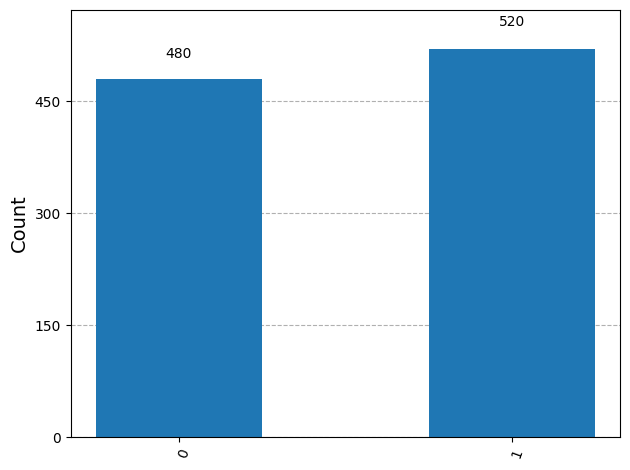

In [8]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 1. Initialise circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# 2. Apply H gate
qc.h(0)

# 3. Measure qubit 0 into cbit 0
qc.measure(0, 0) # Try measuring without the cbit and see what happens

# 4. Instantiate hardware
sim = AerSimulator()

# 5. Run the circuit on the (virtual) hardware
job = sim.run(qc, shots=1000)
result = job.result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

## Exercise:
### What happens if you run the cell above again? 

### What if you mess around with the number of shots? 

### What if you remove the Hadamard gate?

# Homework

Go through the following notebook from IBM Quantum in preparation for the next module
https://quantum.cloud.ibm.com/learning/en/modules/quantum-mechanics/superposition-with-qiskit